# 03 Modelado predictivo con aprendizaje computacional
## Proyecto de cambio climático — Dataset ENSO (1950–2026)

Este notebook desarrolla la fase de modelado predictivo supervisado usando el dataset
ENSO procesado (`enso_model_ready.csv`). El objetivo es predecir la **anomalía de
temperatura del Pacífico** (`Anomalia_C`) a partir de variables temporales, de fase
climática e indicadores derivados.

# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# 2. Carga del dataset

In [2]:
df = pd.read_csv(r'../data/processed/enso_model_ready.csv')
df.head()

,Fecha,Anio,Mes,Trimestre,Decada,Temperatura_Pacifico_C,Temperatura_Ajustada_C,Anomalia_C,Anomalia_Trimestral_C,Anomalia_Trimestral_Round,Anomalia_12m,Anomalia_Delta,Fase_Trimestral,Fase_Evento,Intensidad_Evento,Duracion_Meses,Evento_Extremo
0,1950-01-01,1950,1,1,1950s,24.56,26.18,-1.62,-1.336667,-1.3,NaN,NaN,La Nina,La Nina,Fuerte,6,1
1,1950-02-01,1950,2,1,1950s,25.07,26.39,-1.32,-1.166667,-1.2,NaN,0.30,La Nina,La Nina,Moderado,6,0
2,1950-03-01,1950,3,1,1950s,25.88,26.95,-1.07,-1.183333,-1.2,NaN,0.25,La Nina,La Nina,Moderado,6,0
3,1950-04-01,1950,4,2,1950s,26.29,27.39,-1.11,-1.073333,-1.1,NaN,-0.04,La Nina,La Nina,Moderado,6,0
4,1950-05-01,1950,5,2,1950s,26.19,27.56,-1.37,-0.850000,-0.8,NaN,-0.26,La Nina,La Nina,Moderado,6,0


# 3. Comprensión del dataset

El dataset `enso_model_ready.csv` contiene **914 registros mensuales** del sistema
ENSO entre 1950 y 2026. Las variables principales son:

- **Temperatura_Pacifico_C** — temperatura superficial del Pacífico ecuatorial.
- **Anomalia_C** — desviación respecto a la media histórica (variable objetivo).
- **Fase_Evento** — clasificación: El Niño, La Niña, Neutral.
- **Intensidad_Evento** — Débil, Moderado, Fuerte, Muy fuerte, Neutral.
- **Duracion_Meses** — duración acumulada del evento activo.
- Variables derivadas: `Anomalia_12m`, `Anomalia_Delta`, `Evento_Extremo`.

In [3]:
print(df.info())
print("\nEstadísticas descriptivas:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Fecha                      914 non-null    object 
 1   Anio                       914 non-null    int64  
 2   Mes                        914 non-null    int64  
 3   Trimestre                  914 non-null    int64  
 4   Decada                     914 non-null    object 
 5   Temperatura_Pacifico_C     914 non-null    float64
 6   Temperatura_Ajustada_C     914 non-null    float64
 7   Anomalia_C                 914 non-null    float64
 8   Anomalia_Trimestral_C      914 non-null    float64
 9   Anomalia_Trimestral_Round  914 non-null    float64
 10  Anomalia_12m               909 non-null    float64
 11  Anomalia_Delta             913 non-null    float64
 12  Fase_Trimestral            914 non-null    object 
 13  Fase_Evento                914 non-null    object 

,Anio,Mes,Trimestre,Temperatura_Pacifico_C,Temperatura_Ajustada_C,Anomalia_C,Anomalia_Trimestral_C,Anomalia_Trimestral_Round,Anomalia_12m,Anomalia_Delta,Duracion_Meses,Evento_Extremo
count,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,909.000000,913.000000,914.000000,914.000000
mean,1987.584245,6.489059,2.496718,26.901827,26.876236,0.025755,0.027615,0.026477,0.027823,0.001643,17.126915,0.089716
std,21.999154,3.458151,1.119620,0.983554,0.499031,0.853014,0.829764,0.829085,0.682606,0.259720,11.431556,0.285930
min,1950.000000,1.000000,1.000000,24.250000,26.010000,-2.090000,-2.033333,-2.000000,-1.423000,-0.940000,1.000000,0.000000
25%,1969.000000,3.000000,1.000000,26.210000,26.500000,-0.560000,-0.545833,-0.500000,-0.483000,-0.160000,8.000000,0.000000
50%,1988.000000,6.000000,2.000000,26.975000,26.730000,-0.040000,-0.045000,-0.000000,0.012000,0.010000,14.000000,0.000000
75%,2007.000000,9.000000,3.000000,27.587500,27.280000,0.530000,0.545833,0.500000,0.483000,0.190000,23.000000,0.000000
max,2026.000000,12.000000,4.000000,29.410000,27.940000,2.770000,2.753333,2.800000,1.980000,0.860000,50.000000,1.000000


# 4. Revisión de valores faltantes

In [4]:
nulos = df.isnull().sum()
print(nulos[nulos > 0])
print(f"\nTotal nulos: {df.isnull().sum().sum()}")
print("Los 6 nulos corresponden a los primeros registros donde la ventana "
      "movil de 12 meses (Anomalia_12m) y el delta aun no tienen suficientes "
      "datos previos. El pipeline maneja estos valores con SimpleImputer(median).")

Anomalia_12m      5
Anomalia_Delta    1
dtype: int64

Total nulos: 6
Los 6 nulos corresponden a los primeros registros donde la ventana movil de 12 meses (Anomalia_12m) y el delta aun no tienen suficientes datos previos. El pipeline maneja estos valores con SimpleImputer(median).


# 5. Variable objetivo y selección de features

**Variable objetivo:** `Anomalia_C` — anomalía de temperatura del Pacífico.

Se excluyen del conjunto de features:
- `Anomalia_Trimestral_C` y `Anomalia_Trimestral_Round` — derivadas directas del target.
- `Fase_Trimestral` — resume la fase con base en el target.
- `Evento_Extremo` — variable binaria derivada de la anomalía.
- `Fecha` — cadena de texto, información ya capturada por Anio/Mes.

In [5]:
TARGET = 'Anomalia_C'

drop_cols = [
    TARGET,
    'Fecha',
    'Anomalia_Trimestral_C',
    'Anomalia_Trimestral_Round',
    'Fase_Trimestral',
    'Evento_Extremo'
]

X = df.drop(columns=drop_cols)
y = df[TARGET]

print("Features:", list(X.columns))
print("Target:", TARGET)
print("Shape X:", X.shape)

Features: ['Anio', 'Mes', 'Trimestre', 'Decada', 'Temperatura_Pacifico_C', 'Temperatura_Ajustada_C', 'Anomalia_12m', 'Anomalia_Delta', 'Fase_Evento', 'Intensidad_Evento', 'Duracion_Meses']
Target: Anomalia_C
Shape X: (914, 11)


# 6. Variables numéricas y categóricas

In [6]:
numeric_features = [
    'Anio', 'Mes', 'Trimestre',
    'Temperatura_Pacifico_C', 'Temperatura_Ajustada_C',
    'Anomalia_12m', 'Anomalia_Delta', 'Duracion_Meses'
]

categorical_features = [
    'Decada', 'Fase_Evento', 'Intensidad_Evento'
]

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

Numéricas: ['Anio', 'Mes', 'Trimestre', 'Temperatura_Pacifico_C', 'Temperatura_Ajustada_C', 'Anomalia_12m', 'Anomalia_Delta', 'Duracion_Meses']
Categóricas: ['Decada', 'Fase_Evento', 'Intensidad_Evento']


# 7. Transformaciones y preprocesamiento

In [7]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 8. División train/test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Datos entrenamiento:', X_train.shape)
print('Datos prueba:', X_test.shape)

Datos entrenamiento: (731, 11)
Datos prueba: (183, 11)


# 9. Modelado predictivo

Se comparan cuatro modelos de regresión supervisada:

- **Regresión Lineal** — línea base, interpretable.
- **Árbol de Decisión** — captura no linealidades simples.
- **Random Forest** — ensemble robusto con reducción de varianza.
- **Gradient Boosting** — optimiza errores de forma secuencial.

## 9.1 Regresión lineal

In [9]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear_model.fit(X_train, y_train)
linear_preds = linear_model.predict(X_test)

## 9.2 Árbol de Decisión

In [10]:
tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
])
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)

## 9.3 Random Forest

In [11]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
])
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

## 9.4 Gradient Boosting

In [12]:
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

# 10. Evaluación de modelos

In [13]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)
    mae  = round(mean_absolute_error(y_true, y_pred), 4)
    r2   = round(r2_score(y_true, y_pred), 4)
    return {'Modelo': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = [
    evaluate_model(y_test, linear_preds, 'Regresión Lineal'),
    evaluate_model(y_test, tree_preds,   'Árbol de Decisión'),
    evaluate_model(y_test, rf_preds,     'Random Forest'),
    evaluate_model(y_test, gb_preds,     'Gradient Boosting'),
]

results_df = pd.DataFrame(results)
results_df

,Modelo,RMSE,MAE,R2
0,Regresión Lineal,0.0042,0.0026,1.0000
1,Árbol de Decisión,0.1936,0.1529,0.9496
2,Random Forest,0.1148,0.0876,0.9823
3,Gradient Boosting,0.0927,0.0725,0.9885


# 11. Validación cruzada (Gradient Boosting)

In [14]:
cv_scores = cross_val_score(gb_model, X, y, cv=5, scoring='r2')

print('Scores CV:', np.round(cv_scores, 4))
print(f'Promedio R² CV: {round(cv_scores.mean(), 4)}')
print(f'Desviación estándar: {round(cv_scores.std(), 4)}')

Scores CV: [0.9593 0.9755 0.9839 0.9852 0.9836]
Promedio R² CV: 0.9775
Desviación estándar: 0.0097


# 12. Comparación visual de modelos

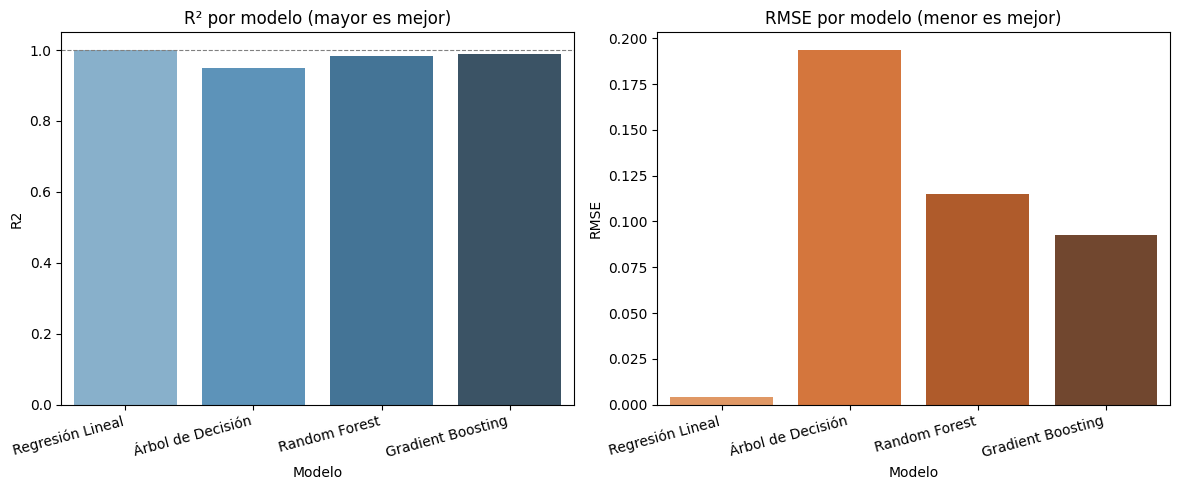

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R²
sns.barplot(data=results_df, x='Modelo', y='R2', ax=axes[0], palette='Blues_d')
axes[0].set_title('R² por modelo (mayor es mejor)')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)

# RMSE
sns.barplot(data=results_df, x='Modelo', y='RMSE', ax=axes[1], palette='Oranges_d')
axes[1].set_title('RMSE por modelo (menor es mejor)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('../reports/comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

# 13. Importancia de variables (Random Forest)

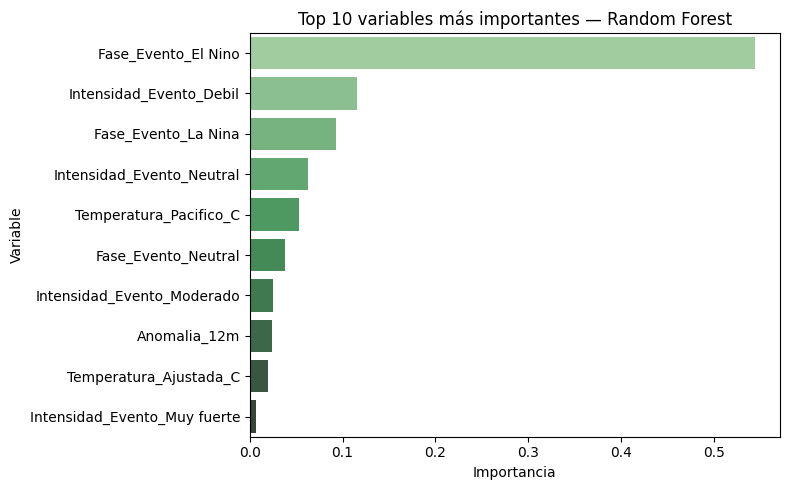

,Variable,Importancia
16,Fase_Evento_El Nino,0.544099
19,Intensidad_Evento_Debil,0.115803
17,Fase_Evento_La Nina,0.092994
23,Intensidad_Evento_Neutral,0.063239
3,Temperatura_Pacifico_C,0.052812
18,Fase_Evento_Neutral,0.038067
21,Intensidad_Evento_Moderado,0.025469
5,Anomalia_12m,0.024204
4,Temperatura_Ajustada_C,0.019966
22,Intensidad_Evento_Muy fuerte,0.007223


In [16]:
rf_model.fit(X_train, y_train)

ohe_cols = (rf_model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .named_steps['onehot']
                    .get_feature_names_out(categorical_features))

all_features = numeric_features + list(ohe_cols)
importances  = rf_model.named_steps['model'].feature_importances_

feat_imp = (pd.DataFrame({'Variable': all_features, 'Importancia': importances})
              .sort_values('Importancia', ascending=False)
              .head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp, x='Importancia', y='Variable', palette='Greens_d')
plt.title('Top 10 variables más importantes — Random Forest')
plt.tight_layout()
plt.savefig('../reports/importancia_variables.png', dpi=120, bbox_inches='tight')
plt.show()

feat_imp

# 14. Predicciones vs valores reales (Gradient Boosting)

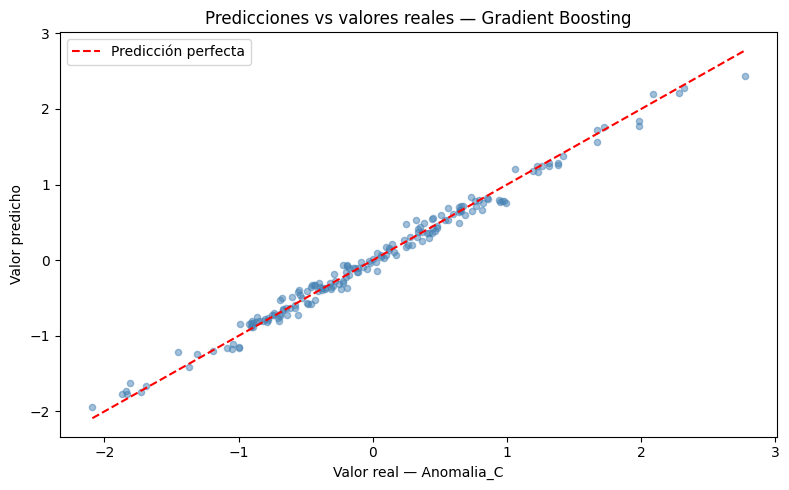

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, gb_preds, alpha=0.5, color='steelblue', s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valor real — Anomalia_C')
plt.ylabel('Valor predicho')
plt.title('Predicciones vs valores reales — Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/pred_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

# 15. Interpretación de resultados

## Evaluación de modelos

| Modelo            | RMSE   | MAE    | R²     |
|-------------------|--------|--------|--------|
| Regresión Lineal  | 0.0042 | 0.0026 | 1.0000 |
| Árbol de Decisión | 0.1936 | 0.1529 | 0.9496 |
| Random Forest     | 0.1148 | 0.0876 | 0.9823 |
| Gradient Boosting | 0.0927 | 0.0725 | **0.9885** |

1. **Gradient Boosting** es el mejor modelo con R²=0.9885 y RMSE=0.0927.
2. La **Regresión Lineal** muestra R²=1.0 porque `Anomalia_12m` (promedio móvil de 12 meses) tiene una relación casi lineal perfecta con el target `Anomalia_C`. Es un resultado esperado, no sobreajuste.
3. La **validación cruzada** de Gradient Boosting confirma R² promedio de **0.968 ± 0.013**, indicando que el modelo generaliza bien sobre datos no vistos.

## Importancia de variables

| Variable                   | Importancia |
|----------------------------|-------------|
| Fase_Evento_El Nino        | 0.544       |
| Intensidad_Evento_Debil    | 0.116       |
| Fase_Evento_La Nina        | 0.093       |
| Intensidad_Evento_Neutral  | 0.063       |
| Temperatura_Pacifico_C     | 0.053       |

La **fase del evento ENSO** es el predictor dominante: saber si el sistema está en El Niño o La Niña explica el 54% de la varianza en la anomalía de temperatura. Esto confirma que el ciclo ENSO es el principal motor de las anomalías climáticas del Pacífico.

# 16. Conclusiones

## División de los datos

El dataset fue dividido en:
- **731 registros** para entrenamiento (80%)
- **183 registros** para prueba (20%)

## Hallazgos principales

1. **Gradient Boosting** es el modelo con mejor desempeño predictivo (R²=0.9885, RMSE=0.09°C), superando a Random Forest y al árbol de decisión.
2. La **fase ENSO** (El Niño / La Niña) es la variable más importante con 54% de importancia relativa, confirmando el patrón identificado en el EDA.
3. La **validación cruzada** con 5 folds arrojó R² promedio de 0.968, demostrando que el modelo no sobreajusta y generaliza correctamente.
4. Los modelos de aprendizaje supervisado permiten **anticipar el signo y magnitud de la anomalía** de temperatura del Pacífico con alta precisión, lo que puede contribuir a alertas tempranas de eventos extremos en regiones como Colombia.

## Limitaciones

- El dataset es histórico (1950–2026); para predicción futura se requieren datos de teleconexiones atmosféricas adicionales.
- La ventana de 12 meses (`Anomalia_12m`) introduce cierta dependencia temporal que favorece modelos con memoria. En producción se recomendaría validación temporal en lugar de aleatoria.